In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
fashion=fetch_openml("Fashion-MNIST",version=1,as_frame=False)
x,y=fashion.data,fashion.target.astype(int)

In [5]:
rng=np.random.RandomState(42)
idx=rng.choice(len(x),6000,replace=False)

In [6]:
x,y=x[idx]/255.0,y[idx]

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42,stratify=y)

In [8]:
k_values=[1,3,5,7,9,11]
accuracies=[]

In [9]:
for k in k_values:
  knn=KNeighborsClassifier(n_neighbors=k)
  start=time.time()
  knn.fit(x_train,y_train)
  y_pred=knn.predict(x_test)
  elapsed=time.time()-start
  acc=accuracy_score(y_test,y_pred)
  accuracies.append(acc)
  print(f"K={k}: Accuracy={acc:.4f}, Time={elapsed:.2f}s")

K=1: Accuracy=0.7892, Time=0.56s
K=3: Accuracy=0.8075, Time=0.58s
K=5: Accuracy=0.8067, Time=0.55s
K=7: Accuracy=0.7983, Time=0.50s
K=9: Accuracy=0.7917, Time=0.49s
K=11: Accuracy=0.7950, Time=0.55s


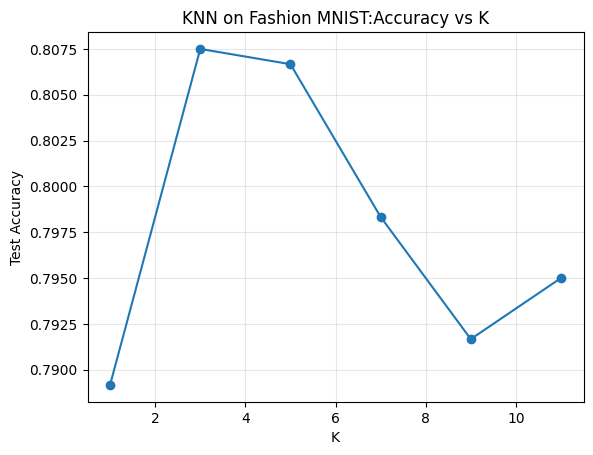

In [10]:
plt.plot(k_values,accuracies,marker="o")
plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("KNN on Fashion MNIST:Accuracy vs K")
plt.grid(alpha=.3)
plt.show()